In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Encontrar raíz del proyecto
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Cargar dataset limpio
df = pd.read_csv(project_root / 'data' / 'clean.csv',
                 parse_dates=['Order Date', 'Ship Date'])

print("Shape:", df.shape)
print("Columnas:", df.shape[1])
print("Periodo:", df['Order Date'].min().date(), "→", df['Order Date'].max().date())
print("Clientes únicos:", df['Customer ID'].nunique())
print("Productos únicos:", df['Product ID'].nunique())
print("Pedidos únicos:", df['Order ID'].nunique())

Shape: (9994, 27)
Columnas: 27
Periodo: 2014-01-03 → 2017-12-30
Clientes únicos: 793
Productos únicos: 1862
Pedidos únicos: 5009


In [2]:
# Métricas por cliente
customer = df.groupby(['Customer ID', 'Customer Name', 'Segment']).agg(
    Orders=('Order ID', 'nunique'),
    Items=('Quantity', 'sum'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    FirstOrder=('Order Date', 'min'),
    LastOrder=('Order Date', 'max')
).reset_index()

customer['AOV'] = (customer['Sales'] / customer['Orders']).round(2)
customer['Margen'] = (customer['Profit'] / customer['Sales'] * 100).round(2)
customer['DiasActivo'] = (customer['LastOrder'] - customer['FirstOrder']).dt.days

print("=== TOP 10 CLIENTES POR VENTAS ===")
print(customer.nlargest(10, 'Sales')[
    ['Customer Name', 'Segment', 'Orders', 'Sales', 'Profit', 'AOV']
].to_string(index=False))

print("\n=== RESUMEN POR SEGMENTO ===")
seg = df.groupby('Segment').agg(
    Clientes=('Customer ID', 'nunique'),
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    TicketMedio=('Sales', 'mean')
).round(2)
seg['Margen%'] = (seg['Profit'] / seg['Sales'] * 100).round(2)
print(seg)

=== TOP 10 CLIENTES POR VENTAS ===
     Customer Name     Segment  Orders     Sales     Profit     AOV
       Sean Miller Home Office       5 25043.050 -1980.7393 5008.61
      Tamara Chand   Corporate       5 19052.218  8981.3239 3810.44
      Raymond Buch    Consumer       6 15117.339  6976.0959 2519.56
      Tom Ashbrook Home Office       4 14595.620  4703.7883 3648.90
     Adrian Barton    Consumer      10 14473.571  5444.8055 1447.36
      Ken Lonsdale    Consumer      12 14175.229   806.8550 1181.27
      Sanjit Chand    Consumer       9 14142.334  5757.4119 1571.37
      Hunter Lopez    Consumer       6 12873.298  5622.4292 2145.55
      Sanjit Engle    Consumer      11 12209.438  2650.6769 1109.95
Christopher Conant    Consumer       5 12129.072  2177.0493 2425.81

=== RESUMEN POR SEGMENTO ===
             Clientes  Orders       Sales     Profit  TicketMedio  Margen%
Segment                                                                   
Consumer          409    2586  116140

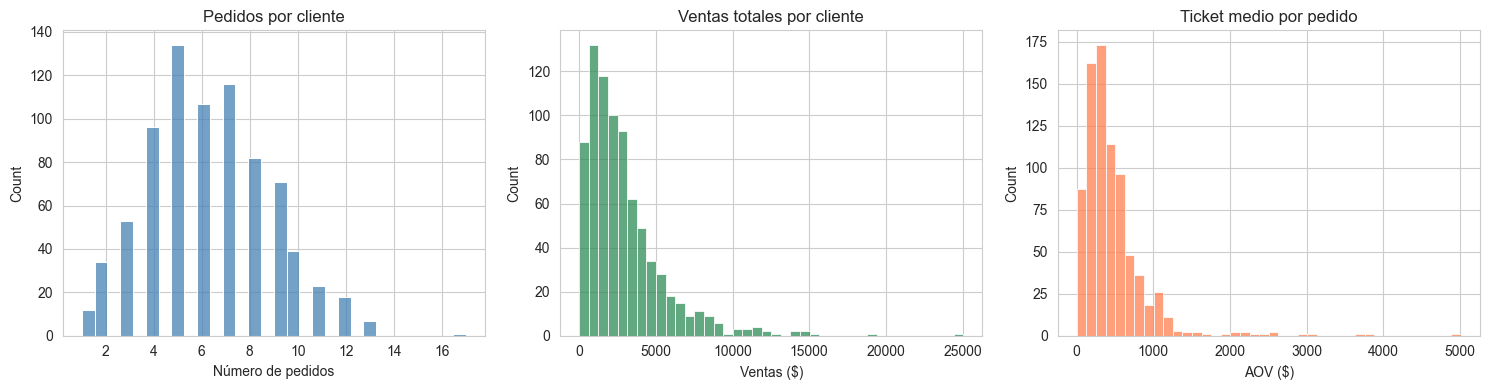

Clientes con 1 solo pedido: 12 (1.5%)
Clientes con 5+ pedidos: 598 (75.4%)

Estadísticas de ventas por cliente:
count      793.00
mean      2896.85
std       2628.67
min          4.83
25%       1146.05
50%       2256.39
75%       3785.28
max      25043.05
Name: Sales, dtype: float64


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de pedidos por cliente
sns.histplot(customer['Orders'], bins=30, ax=ax[0], color='steelblue')
ax[0].set_title('Pedidos por cliente')
ax[0].set_xlabel('Número de pedidos')

# Distribución de ventas por cliente
sns.histplot(customer['Sales'], bins=40, ax=ax[1], color='seagreen')
ax[1].set_title('Ventas totales por cliente')
ax[1].set_xlabel('Ventas ($)')

# Distribución del AOV
sns.histplot(customer['AOV'], bins=40, ax=ax[2], color='coral')
ax[2].set_title('Ticket medio por pedido')
ax[2].set_xlabel('AOV ($)')

plt.tight_layout()
plt.show()

# Estadísticas clave
print("Clientes con 1 solo pedido:", (customer['Orders'] == 1).sum(),
      f"({(customer['Orders'] == 1).mean()*100:.1f}%)")
print("Clientes con 5+ pedidos:", (customer['Orders'] >= 5).sum(),
      f"({(customer['Orders'] >= 5).mean()*100:.1f}%)")
print("\nEstadísticas de ventas por cliente:")
print(customer['Sales'].describe().round(2))

In [4]:
from datetime import timedelta

# Fecha de referencia: un día después de la última orden
snapshot = df['Order Date'].max() + timedelta(days=1)
print("Fecha de referencia (snapshot):", snapshot.date())

# Calcular R, F, M por cliente
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

# Puntuación por cuartiles (1-4)
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

# Score concatenado
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print("\n=== ESTADÍSTICAS RFM ===")
print(rfm[['Recency', 'Frequency', 'Monetary', 'Profit']].describe().round(2))

print("\n=== DISTRIBUCIÓN DE SCORES ===")
print(rfm[['R', 'F', 'M']].apply(pd.Series.value_counts).sort_index())

Fecha de referencia (snapshot): 2017-12-31

=== ESTADÍSTICAS RFM ===
       Recency  Frequency  Monetary   Profit
count   793.00     793.00    793.00   793.00
mean    147.80       6.32   2896.85   361.16
std     186.21       2.55   2628.67   894.26
min       1.00       1.00      4.83 -6626.39
25%      31.00       5.00   1146.05    36.61
50%      76.00       6.00   2256.39   227.83
75%     184.00       8.00   3785.28   560.01
max    1166.00      17.00  25043.05  8981.32

=== DISTRIBUCIÓN DE SCORES ===
     R    F    M
1  196  199  199
2  200  198  198
3  194  198  198
4  203  198  198


In [5]:
def segmentar(row):
    if row['R'] >= 4 and row['F'] >= 4 and row['M'] >= 4:
        return 'Champions'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Leales'
    elif row['R'] >= 4 and row['F'] <= 2:
        return 'Nuevos'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'En riesgo'
    elif row['R'] <= 2 and row['F'] <= 2:
        return 'Perdidos'
    else:
        return 'Necesitan atención'

rfm['Segmento'] = rfm.apply(segmentar, axis=1)

# Resumen por segmento
seg_rfm = rfm.groupby('Segmento').agg(
    Clientes=('Customer ID', 'count'),
    R_medio=('Recency', 'mean'),
    F_medio=('Frequency', 'mean'),
    M_medio=('Monetary', 'mean'),
    Profit_total=('Profit', 'sum')
).round(2)

seg_rfm['% Clientes'] = (seg_rfm['Clientes'] / seg_rfm['Clientes'].sum() * 100).round(1)
seg_rfm['% Ventas'] = (seg_rfm['M_medio'] * seg_rfm['Clientes'] /
                       rfm['Monetary'].sum() * 100).round(1)

print("=== SEGMENTACIÓN RFM ===")
print(seg_rfm.sort_values('Profit_total', ascending=False))

=== SEGMENTACIÓN RFM ===
                    Clientes  R_medio  F_medio  M_medio  Profit_total  \
Segmento                                                                
En riesgo                158   180.67     8.08  3802.78      91673.84   
Leales                   204    35.45     8.28  3443.47      76255.82   
Perdidos                 238   316.50     4.13  1836.93      46843.80   
Champions                 34    16.00    10.09  5863.65      27244.07   
Necesitan atención        85    51.38     4.48  2535.99      27175.20   
Nuevos                    74    16.11     4.55  1915.96      17204.29   

                    % Clientes  % Ventas  
Segmento                                  
En riesgo                 19.9      26.2  
Leales                    25.7      30.6  
Perdidos                  30.0      19.0  
Champions                  4.3       8.7  
Necesitan atención        10.7       9.4  
Nuevos                     9.3       6.2  


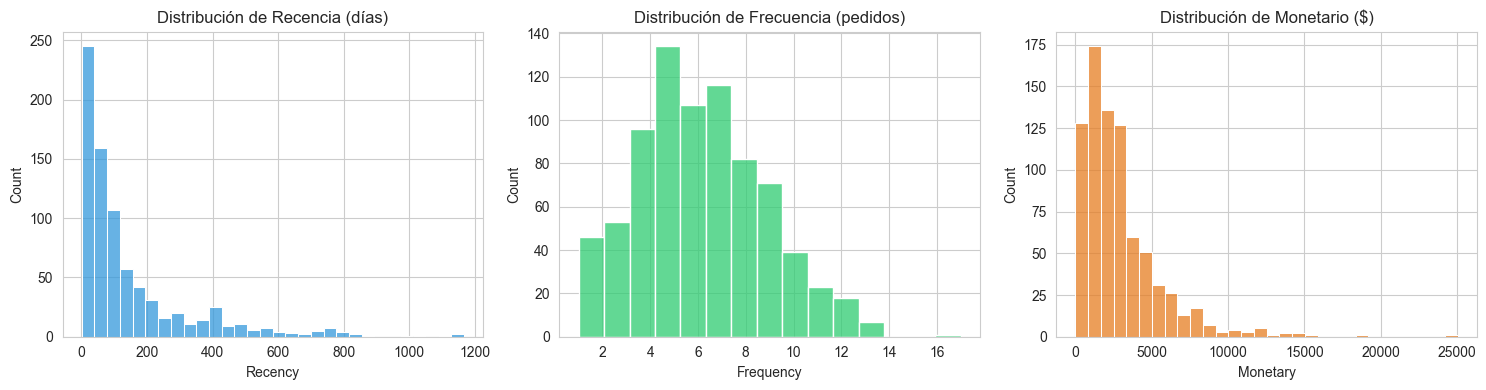

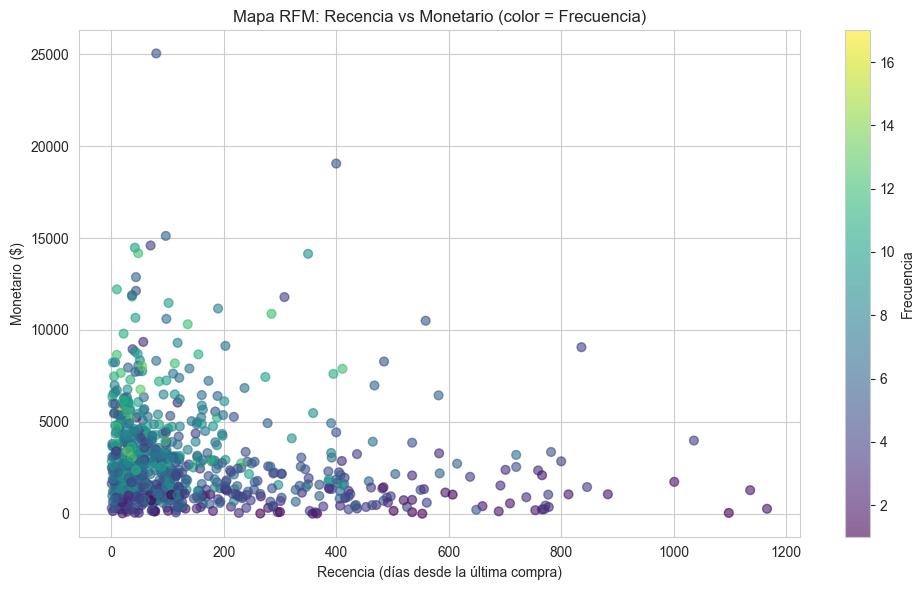

C:\Users\rolan\AppData\Local\Temp\ipykernel_16816\250062420.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segmento',


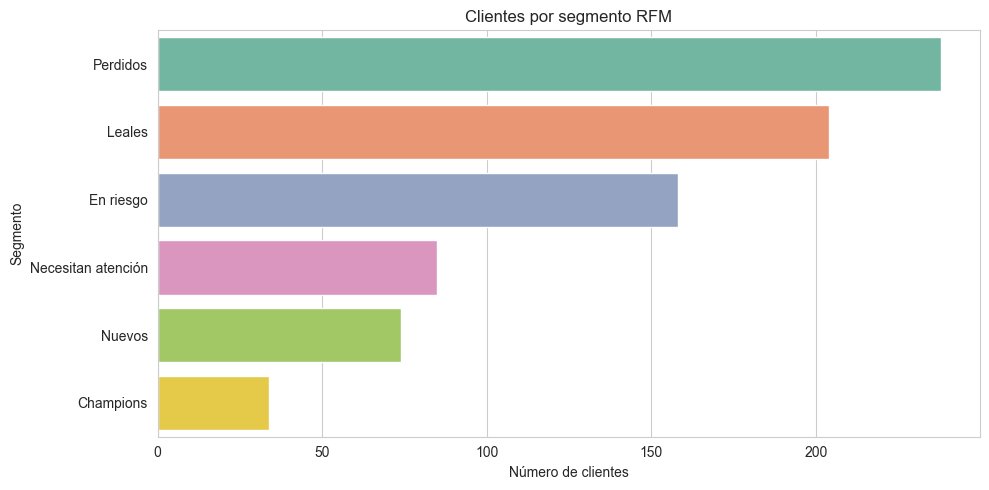

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de R, F, M
sns.histplot(rfm['Recency'], bins=30, ax=ax[0], color='#3498db')
ax[0].set_title('Distribución de Recencia (días)')

sns.histplot(rfm['Frequency'], bins=15, ax=ax[1], color='#2ecc71')
ax[1].set_title('Distribución de Frecuencia (pedidos)')

sns.histplot(rfm['Monetary'], bins=30, ax=ax[2], color='#e67e22')
ax[2].set_title('Distribución de Monetario ($)')

plt.tight_layout()
plt.show()

# Scatter R vs M coloreado por Frecuencia
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'],
                       c=rfm['Frequency'], cmap='viridis',
                       alpha=0.6, s=40)
plt.colorbar(scatter, label='Frecuencia')
plt.xlabel('Recencia (días desde la última compra)')
plt.ylabel('Monetario ($)')
plt.title('Mapa RFM: Recencia vs Monetario (color = Frecuencia)')
plt.tight_layout()
plt.show()

# Clientes por segmento
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y='Segmento',
              order=rfm['Segmento'].value_counts().index,
              palette='Set2')
plt.title('Clientes por segmento RFM')
plt.xlabel('Número de clientes')
plt.tight_layout()
plt.show()

In [7]:
def segmentar_v2(row):
    if row['R'] >= 3 and row['F'] >= 4 and row['M'] >= 4:
        return 'Champions'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Leales'
    elif row['R'] >= 4:
        return 'Nuevos / Prometedores'
    elif row['R'] <= 2 and row['F'] >= 3 and row['M'] >= 3:
        return 'En riesgo (alto valor)'
    elif row['R'] <= 2 and row['F'] <= 2:
        return 'Perdidos (bajo valor)'
    else:
        return 'Necesitan atención'

rfm['Segmento_v2'] = rfm.apply(segmentar_v2, axis=1)

seg_v2 = rfm.groupby('Segmento_v2').agg(
    Clientes=('Customer ID', 'count'),
    R_medio=('Recency', 'mean'),
    F_medio=('Frequency', 'mean'),
    M_medio=('Monetary', 'mean'),
    Profit_total=('Profit', 'sum'),
    Sales_total=('Monetary', 'sum')
).round(2).sort_values('Profit_total', ascending=False)

seg_v2['% Clientes'] = (seg_v2['Clientes'] / seg_v2['Clientes'].sum() * 100).round(1)
seg_v2['% Ventas'] = (seg_v2['Sales_total'] / seg_v2['Sales_total'].sum() * 100).round(1)

print("=== SEGMENTACIÓN RFM v2 ===")
print(seg_v2)

=== SEGMENTACIÓN RFM v2 ===
                        Clientes  R_medio  F_medio  M_medio  Profit_total  \
Segmento_v2                                                                 
En riesgo (alto valor)       107   170.62     8.31  4959.72      82650.16   
Leales                       180    33.64     8.04  3022.15      54474.00   
Champions                     58    29.66    10.09  6169.74      49025.89   
Perdidos (bajo valor)        238   316.50     4.13  1836.93      46843.80   
Necesitan atención           136   107.77     5.65  2100.80      36198.87   
Nuevos / Prometedores         74    16.11     4.55  1915.96      17204.29   

                        Sales_total  % Clientes  % Ventas  
Segmento_v2                                                
En riesgo (alto valor)    530689.63        13.5      23.1  
Leales                    543986.70        22.7      23.7  
Champions                 357845.06         7.3      15.6  
Perdidos (bajo valor)     437189.90        30.0      19

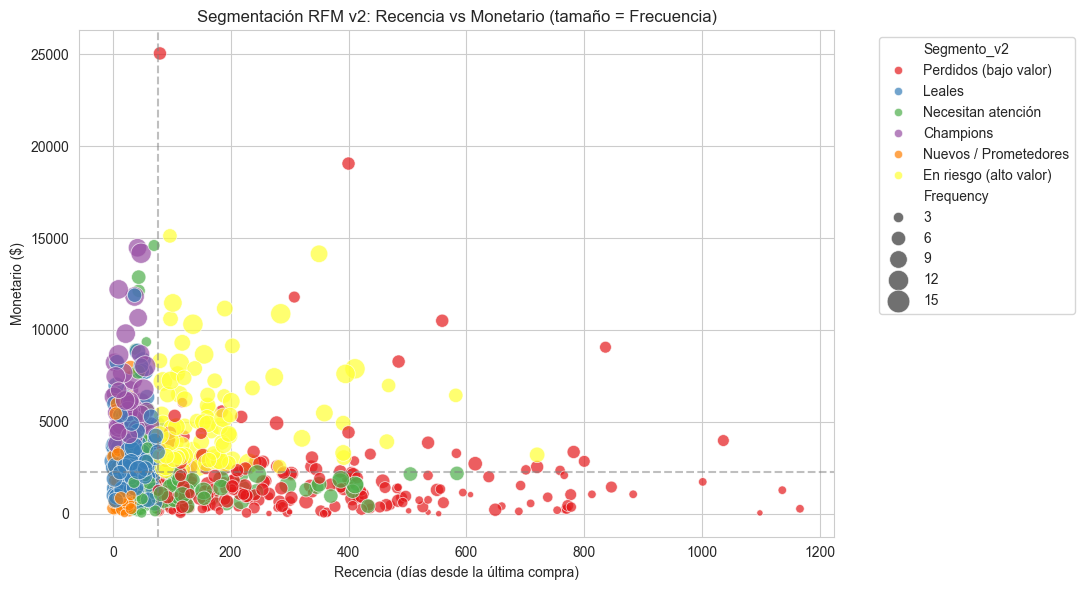

In [8]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=rfm, x='Recency', y='Monetary',
    size='Frequency', sizes=(20, 300),
    hue='Segmento_v2', palette='Set1',
    alpha=0.7
)

plt.axvline(rfm['Recency'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(rfm['Monetary'].median(), color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Recencia (días desde la última compra)')
plt.ylabel('Monetario ($)')
plt.title('Segmentación RFM v2: Recencia vs Monetario (tamaño = Frecuencia)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

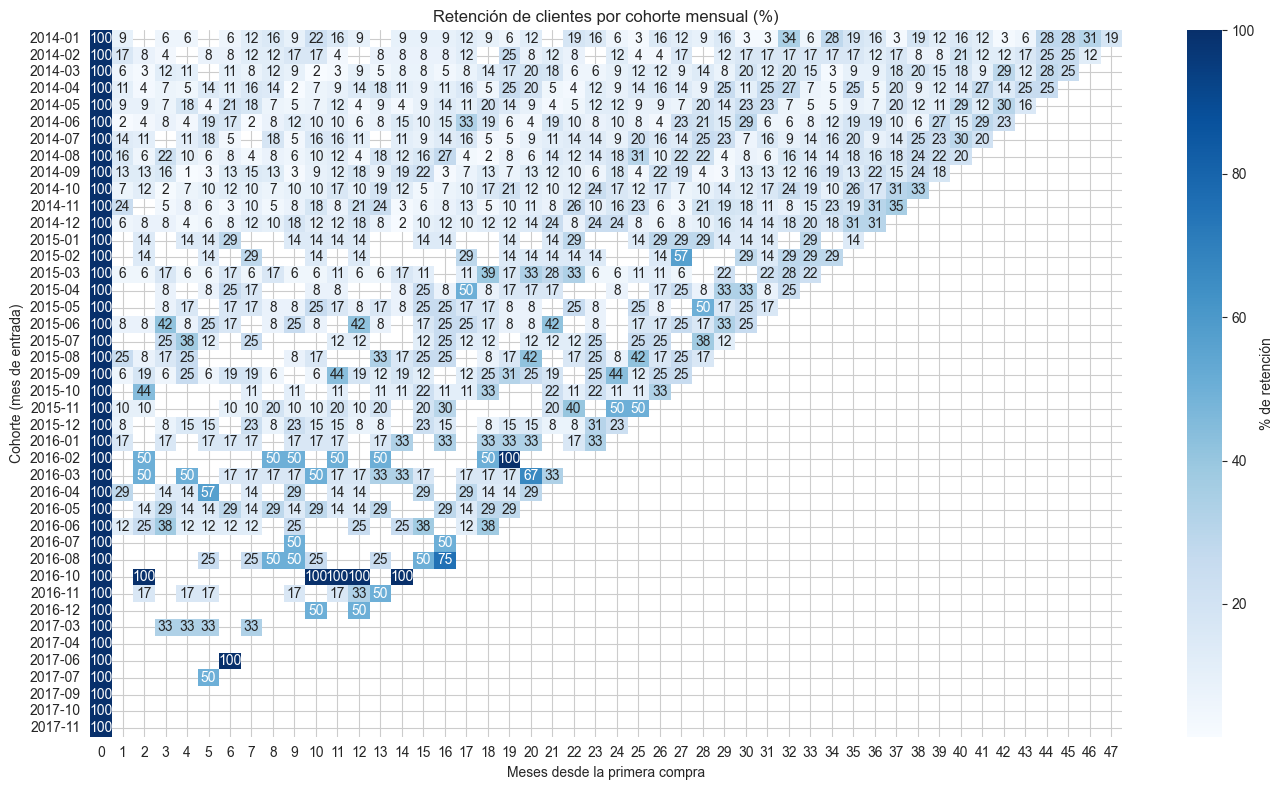

In [9]:
# Cohorte = mes de la primera compra del cliente
df['CohortMonth'] = df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M')
df['OrderMonth']  = df['Order Date'].dt.to_period('M')

# Índice de cohorte = meses desde la primera compra
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Tamaño de cada cohorte (clientes que entran ese mes)
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                  columns='CohortIndex',
                                  values='CustomerID' if 'CustomerID' in cohort_data.columns else 'Customer ID')

# Retención: cada fila / su columna 0 * 100
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '% de retención'})
plt.title('Retención de clientes por cohorte mensual (%)')
plt.xlabel('Meses desde la primera compra')
plt.ylabel('Cohorte (mes de entrada)')
plt.tight_layout()
plt.show()

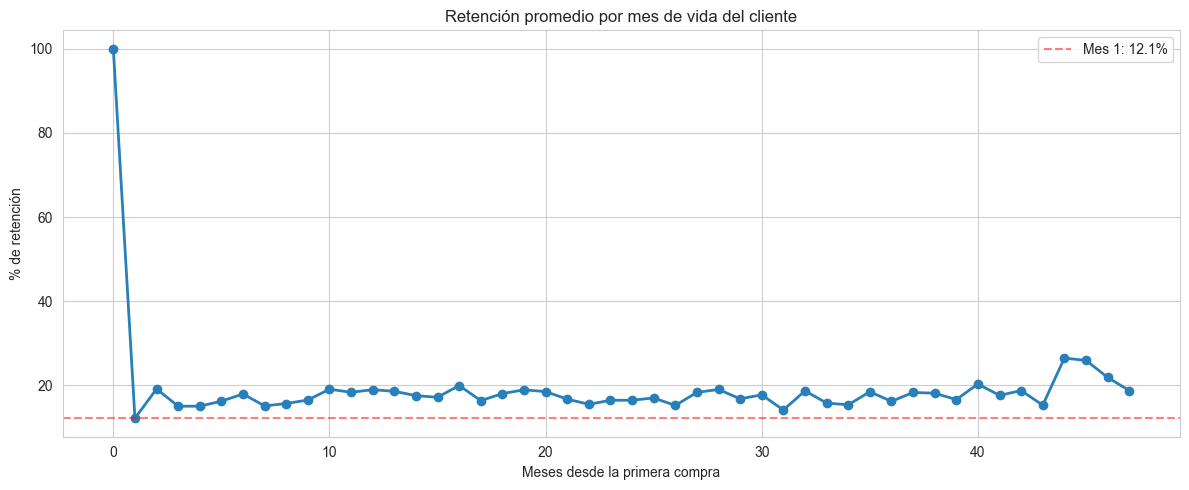

 Mes  Retencion_media_%
   0         100.000000
   1          12.149907
   2          19.116950
   3          15.013246
   4          15.020992
   5          16.210537
   6          17.921922
   7          15.076826
   8          15.657925
   9          16.483902
  10          19.055817
  11          18.332949
  12          18.937217
  13          18.559450
  14          17.531592
  15          17.135891
  16          19.939480
  17          16.344594
  18          18.012103
  19          18.917354
  20          18.482332
  21          16.696031
  22          15.475432
  23          16.415527
  24          16.440899
  25          16.981689
  26          15.196076
  27          18.302497
  28          18.995317
  29          16.763599
  30          17.719208
  31          14.109814
  32          18.666198
  33          15.771344
  34          15.341428
  35          18.448190
  36          16.167175
  37          18.281948
  38          18.111445
  39          16.593209
  40          20

In [10]:
# Retención media en cada índice de cohorte
avg_retention = retention.mean(axis=0).reset_index()
avg_retention.columns = ['Mes', 'Retencion_media_%']

plt.figure(figsize=(12, 5))
plt.plot(avg_retention['Mes'], avg_retention['Retencion_media_%'],
         marker='o', color='#2980b9', linewidth=2)
plt.axhline(avg_retention['Retencion_media_%'].iloc[1],
            color='red', linestyle='--', alpha=0.5,
            label=f"Mes 1: {avg_retention['Retencion_media_%'].iloc[1]:.1f}%")
plt.title('Retención promedio por mes de vida del cliente')
plt.xlabel('Meses desde la primera compra')
plt.ylabel('% de retención')
plt.legend()
plt.tight_layout()
plt.show()

print(avg_retention.to_string(index=False))

In [11]:
# ============================================
# RESUMEN NOTEBOOK 02 — EDA AVANZADO
# ============================================

print("""
=====================================================
RESUMEN DEL ANÁLISIS DE CLIENTES
=====================================================

1. CLIENTES
   - 793 clientes únicos, 5.009 pedidos (6.3 pedidos/cliente promedio)
   - 75.4% de clientes tienen 5+ pedidos → negocio B2B/recurrente
   - 1.5% de clientes con 1 solo pedido

2. SEGMENTOS DE NEGOCIO
   - Consumer: 409 clientes, margen 11.5%
   - Corporate: 236 clientes, margen 13.0%
   - Home Office: 148 clientes, margen 14.0% (el más rentable)

3. SEGMENTACIÓN RFM
   - En riesgo (alto valor): 13.5% clientes → 23.1% ventas → $82.6K profit
   - Champions: 7.3% clientes → 15.6% ventas → $49.0K profit
   - Perdidos: 30% clientes → solo $46.8K profit (no merecen inversión)

4. RETENCIÓN (COHORTES)
   - Caída brutal del Mes 0 (100%) al Mes 1 (12.1%)
   - Estabilización en el 15-20% durante años
   - Cohortes recientes (2016-2017) muestran mejor retención

5. INSIGHT PRINCIPAL
   Reactivar al segmento "En riesgo (alto valor)" es la palanca
   más rentable del negocio. Son 107 clientes que generaron
   $82.6K de profit y llevan 170 días sin comprar.
=====================================================
""")


RESUMEN DEL ANÁLISIS DE CLIENTES

1. CLIENTES
   - 793 clientes únicos, 5.009 pedidos (6.3 pedidos/cliente promedio)
   - 75.4% de clientes tienen 5+ pedidos → negocio B2B/recurrente
   - 1.5% de clientes con 1 solo pedido

2. SEGMENTOS DE NEGOCIO
   - Consumer: 409 clientes, margen 11.5%
   - Corporate: 236 clientes, margen 13.0%
   - Home Office: 148 clientes, margen 14.0% (el más rentable)

3. SEGMENTACIÓN RFM
   - En riesgo (alto valor): 13.5% clientes → 23.1% ventas → $82.6K profit
   - Champions: 7.3% clientes → 15.6% ventas → $49.0K profit
   - Perdidos: 30% clientes → solo $46.8K profit (no merecen inversión)

4. RETENCIÓN (COHORTES)
   - Caída brutal del Mes 0 (100%) al Mes 1 (12.1%)
   - Estabilización en el 15-20% durante años
   - Cohortes recientes (2016-2017) muestran mejor retención

5. INSIGHT PRINCIPAL
   Reactivar al segmento "En riesgo (alto valor)" es la palanca
   más rentable del negocio. Son 107 clientes que generaron
   $82.6K de profit y llevan 170 días sin co